In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import SeparatorParams, SimConfig
from src.sim_model import simulate_separator_open_loop

In [2]:
#Parameter awal separator
params = SeparatorParams(
    A=3.0,            # m^2
    V_total=12.0,     # m^3
    L_max=3.0,        # m
    V_min=0.2,        # m^3

    rho_l=850.0,      # kg/m^3 (kondensat/oli ringan kira-kira)
    g=9.81,           # m/s^2
    Patm=101_325.0,   # Pa
    P_out=101_325.0,  # Pa

    Cv_l=5e-5,      # m^3/s/sqrt(Pa) (tuning demo)
    R=8.314,          # J/mol/K
    T=320.0,          # K (~47C)

    kg_n_sqrt=0.08,   # mol/s/sqrt(Pa) (tuning demo)
    n_out_max=30.0    # mol/s (kapasitas max vent)
)

sim = SimConfig(dt=0.5, t_end=600.0)

In [3]:
#Definisikan input open loop
def qin_func(t):
    # liquid inflow baseline 0.004 m3/s, naik pada t>200
    return 0.004 + (0.001 if t > 200 else 0.0)

def n_in_func(t):
    # gas inflow baseline 4 mol/s, naik pada t>300
    return 4.0 + (1.5 if t > 300 else 0.0)

def u_func(t):
    # valve opening konstan 0.55 (open-loop)
    return 0.55

In [4]:
#Jalankan simulasi
df = simulate_separator_open_loop(
    params=params,
    sim=sim,
    qin_func=qin_func,
    n_in_func=n_in_func,
    u_func=u_func,
    L0=1.0,
    n0=400.0
)
df.head()

,t_s,qin_m3s,qout_m3s,u,L_m,Vg_m3,n_mol,P_Pa,n_in_mols,n_out_mols,dP_liq_Pa
0,0.0,0.000,0.000000,0.00,1.000000,9.000000,400.000000,118243.555556,0.0,0.000000,0.000000
1,0.5,0.004,0.004370,0.55,0.999938,9.000185,396.797146,117294.349623,4.0,10.405708,25257.055556
2,1.0,0.004,0.004287,0.55,0.999890,9.000329,393.742350,116389.484665,4.0,10.109591,24307.334819
3,1.5,0.004,0.004207,0.55,0.999856,9.000432,390.832852,115528.114746,4.0,9.818997,23402.070346
4,2.0,0.004,0.004129,0.55,0.999834,9.000497,388.065779,114709.362559,4.0,9.534146,22540.412919


In [7]:
df[["n_out_mols", "P_Pa"]].describe()

,n_out_mols,P_Pa
count,1201.000000,1201.000000
mean,4.873960,105158.746680
std,0.869115,1454.454036
min,0.000000,103876.823484
25%,4.043624,103879.855439
50%,5.421659,105940.734720
75%,5.564735,106163.481182
max,10.405708,118243.555556


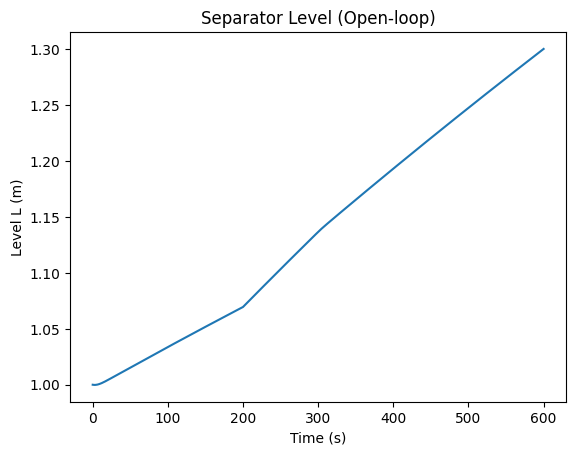

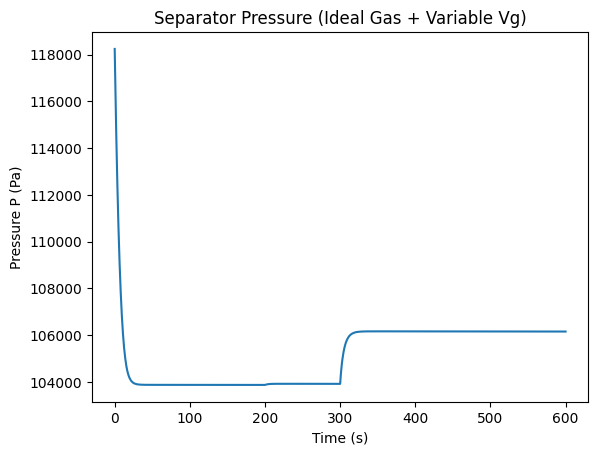

In [8]:
#Plot hasil
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["t_s"], df["L_m"])
plt.xlabel("Time (s)")
plt.ylabel("Level L (m)")
plt.title("Separator Level (Open-loop)")
plt.show()

plt.figure()
plt.plot(df["t_s"], df["P_Pa"])
plt.xlabel("Time (s)")
plt.ylabel("Pressure P (Pa)")
plt.title("Separator Pressure (Ideal Gas + Variable Vg)")
plt.show()

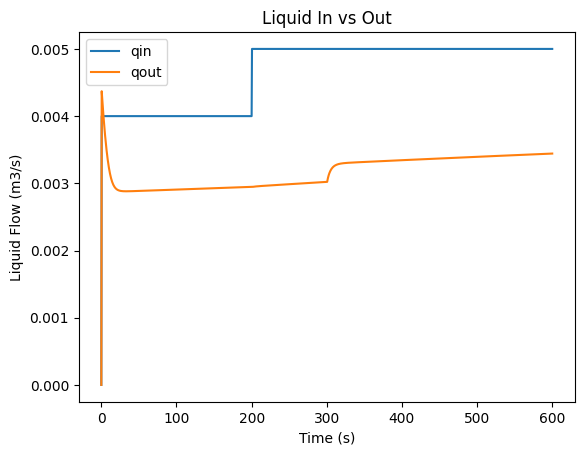

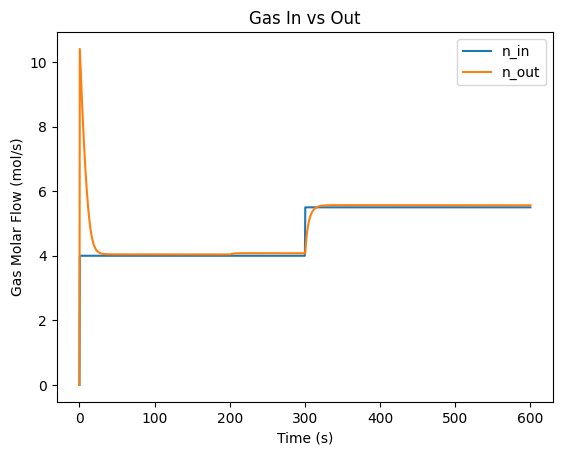

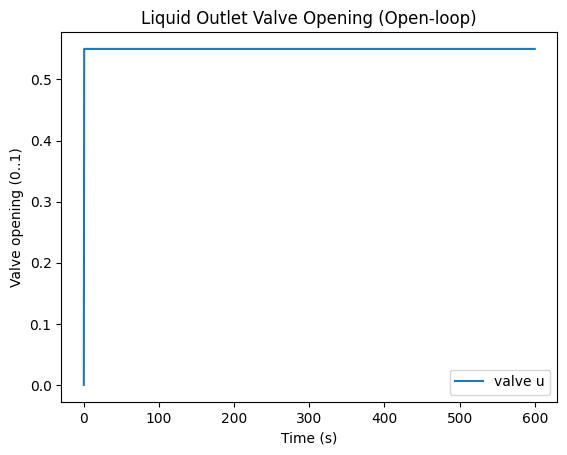

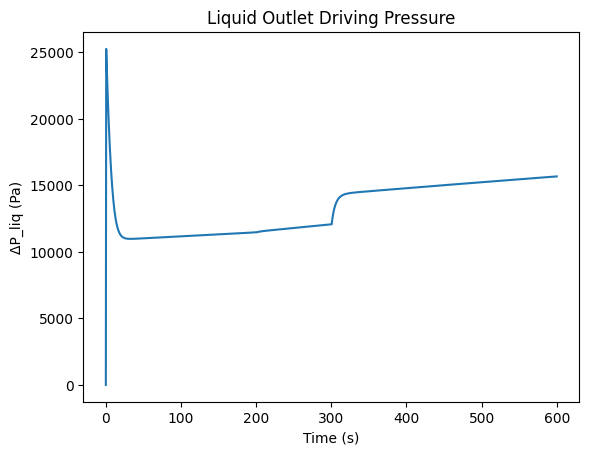

In [6]:
#Plot sebab-akibat (flow, valve, delta_P)
plt.figure()
plt.plot(df["t_s"], df["qin_m3s"], label="qin")
plt.plot(df["t_s"], df["qout_m3s"], label="qout")
plt.xlabel("Time (s)")
plt.ylabel("Liquid Flow (m3/s)")
plt.title("Liquid In vs Out")
plt.legend()
plt.show()

plt.figure()
plt.plot(df["t_s"], df["n_in_mols"], label="n_in")
plt.plot(df["t_s"], df["n_out_mols"], label="n_out")
plt.xlabel("Time (s)")
plt.ylabel("Gas Molar Flow (mol/s)")
plt.title("Gas In vs Out")
plt.legend()
plt.show()

plt.figure()
plt.plot(df["t_s"], df["u"], label="valve u")
plt.xlabel("Time (s)")
plt.ylabel("Valve opening (0..1)")
plt.title("Liquid Outlet Valve Opening (Open-loop)")
plt.legend()
plt.show()

plt.figure()
plt.plot(df["t_s"], df["dP_liq_Pa"])
plt.xlabel("Time (s)")
plt.ylabel("ΔP_liq (Pa)")
plt.title("Liquid Outlet Driving Pressure")
plt.show()